# ***PREPROCESAMIENTO DATASET DIABETES 130-US HOSPITALS***

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler,StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate,GridSearchCV
from sklearn.impute import SimpleImputer,KNNImputer
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix

In [51]:
np.random.seed(22)

## 1- Exploración inicial y tipos de datos

In [52]:
# Cargar datos
df = pd.read_csv('../data/diabetic_data.csv', sep=",", quotechar='"')

print(f"\n Dimensiones del dataset:")
print("-" * 26)
print(f"Filas: {df.shape[0]} | Columnas: {df.shape[1]}")

# Tipos de datos
print("\n Tipos de datos por variable:")
print("-" * 29)
print(df.dtypes)

# Primeras filas
print("\n Primeras filas del dataset:")
print("-" * 28)
print(df.head())

# Valores faltantes
missing = df.isnull().sum()
if missing.sum() == 0:
    print("\n No se han detectado valores faltantes.")
    print("-" * 40)
else:
    print("\n Valores faltantes :")
    print("-" * 27)
    print(df.isnull().sum())
# Resumen 
print("\n Resumen:")
print("-" * 10)
df.info()


 Dimensiones del dataset:
--------------------------
Filas: 101766 | Columnas: 50

 Tipos de datos por variable:
-----------------------------
encounter_id                 int64
patient_nbr                  int64
race                        object
gender                      object
age                         object
weight                      object
admission_type_id            int64
discharge_disposition_id     int64
admission_source_id          int64
time_in_hospital             int64
payer_code                  object
medical_specialty           object
num_lab_procedures           int64
num_procedures               int64
num_medications              int64
number_outpatient            int64
number_emergency             int64
number_inpatient             int64
diag_1                      object
diag_2                      object
diag_3                      object
number_diagnoses             int64
max_glu_serum               object
A1Cresult                   object
metformin       

## 2- Manejo de valores faltantes

In [53]:
cant_null_col1 = df["max_glu_serum"].isnull().sum()
cant_null_col2 = df["A1Cresult"].isnull().sum()

porcentaje_null_col1 = (cant_null_col1/df.shape[0] ) * 100
porcentaje_null_col2 = (cant_null_col2/df.shape[0] ) * 100

print("Cantidad de valores nulos (%)")
print(f"Columna 'max_glu_serum' : {porcentaje_null_col1}%")
print(f"Columna 'A1Cresult' : {porcentaje_null_col2}%")

Cantidad de valores nulos (%)
Columna 'max_glu_serum' : 94.74677200636755%
Columna 'A1Cresult' : 83.27732248491637%


Debido a que más del 50% de los datos de las columnas *max_glu_serum* y *A1Cresult* se procede a la eliminación de la columna

In [65]:
# Estrategia 2: Eliminar columnas con >50% faltantes
df_clean = df.dropna(thresh=len(df)*0.5, axis=1)
print(df_clean.columns)

Index(['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight',
       'admission_type_id', 'discharge_disposition_id', 'admission_source_id',
       'time_in_hospital', 'payer_code', 'medical_specialty',
       'num_lab_procedures', 'num_procedures', 'num_medications',
       'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1',
       'diag_2', 'diag_3', 'number_diagnoses', 'metformin', 'repaglinide',
       'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide',
       'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone',
       'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide',
       'examide', 'citoglipton', 'insulin', 'glyburide-metformin',
       'glipizide-metformin', 'glimepiride-pioglitazone',
       'metformin-rosiglitazone', 'metformin-pioglitazone', 'change',
       'diabetesMed', 'readmitted'],
      dtype='object')


## 3- Tratamiento de outliers

ENCOUNTER_ID
  Outliers detectados: 0


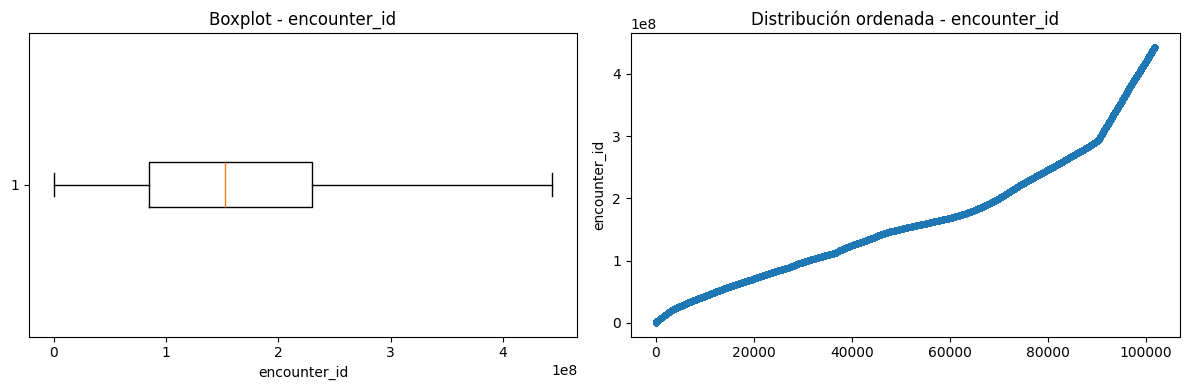

PATIENT_NBR
  Outliers detectados: 247


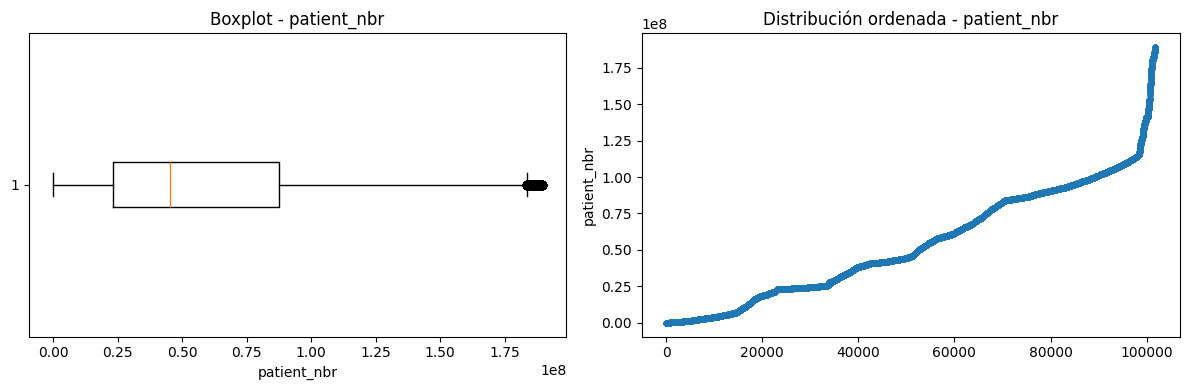

ADMISSION_TYPE_ID
  Outliers detectados: 341


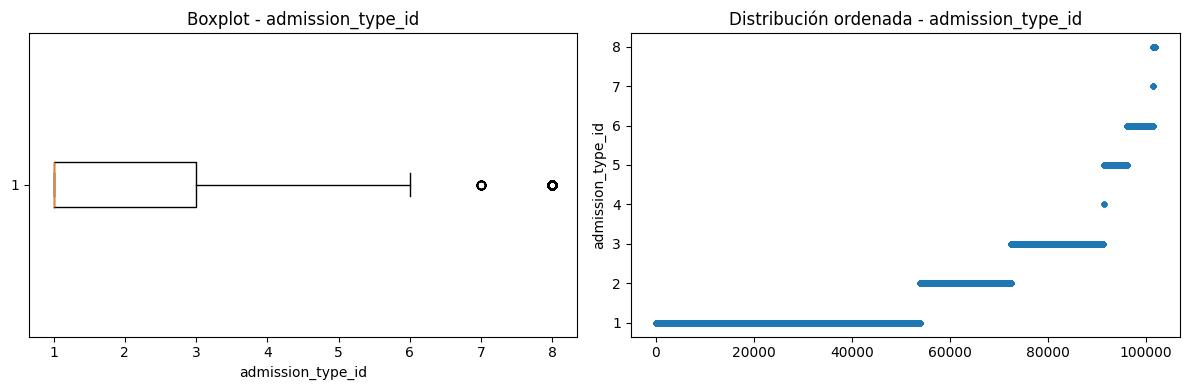

DISCHARGE_DISPOSITION_ID
  Outliers detectados: 9818


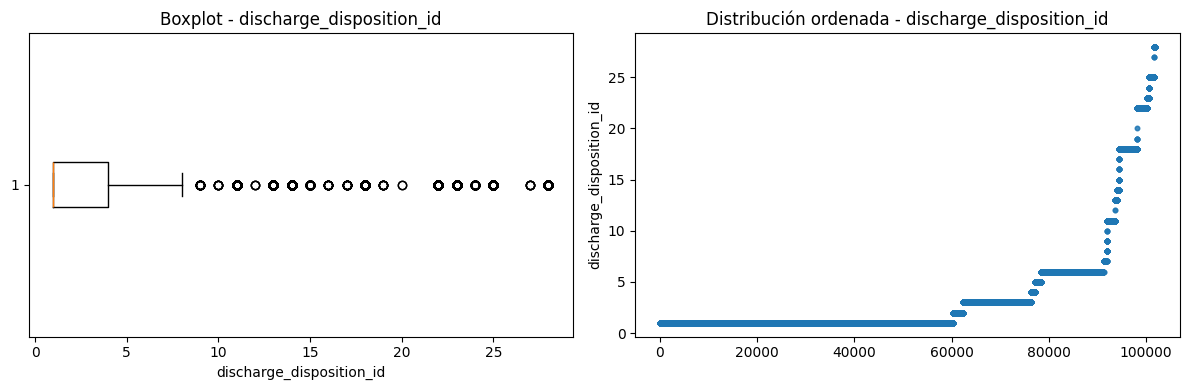

ADMISSION_SOURCE_ID
  Outliers detectados: 6956


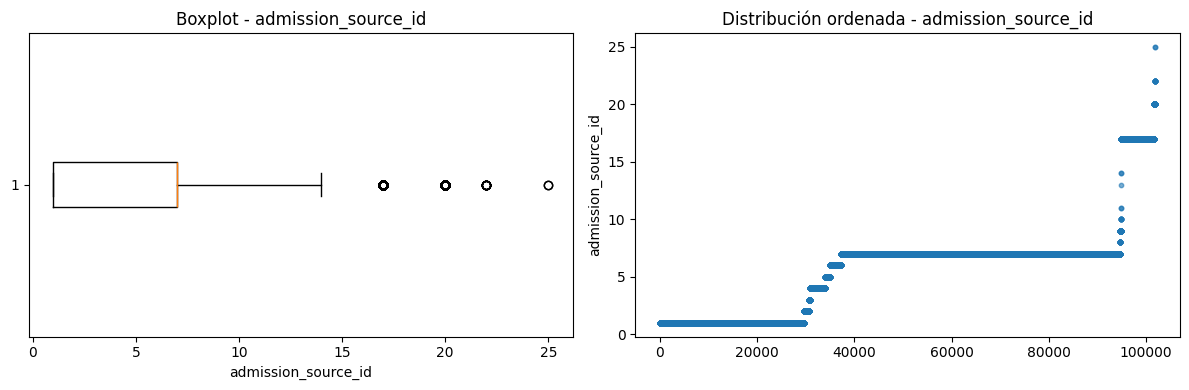

TIME_IN_HOSPITAL
  Outliers detectados: 2252


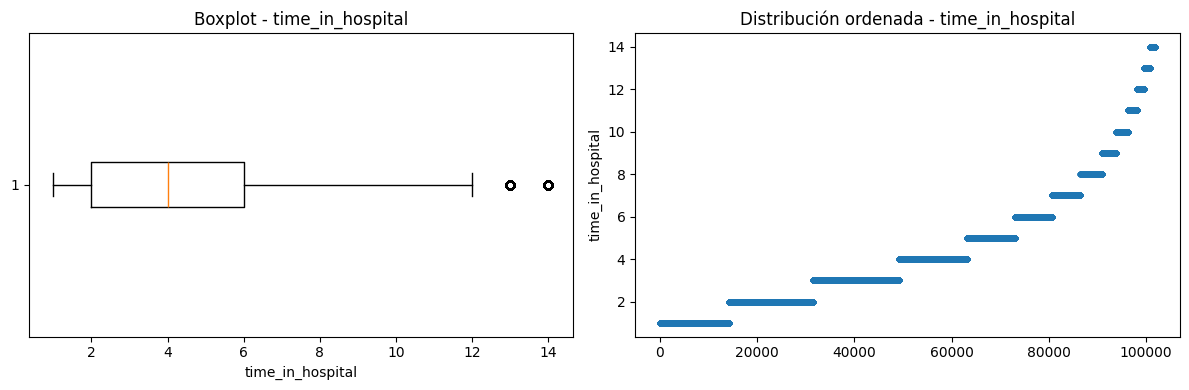

NUM_LAB_PROCEDURES
  Outliers detectados: 143


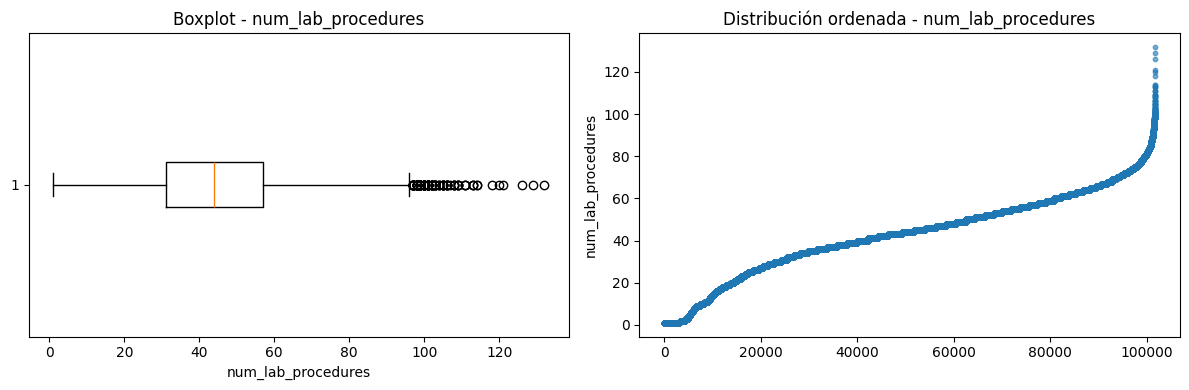

NUM_PROCEDURES
  Outliers detectados: 4954


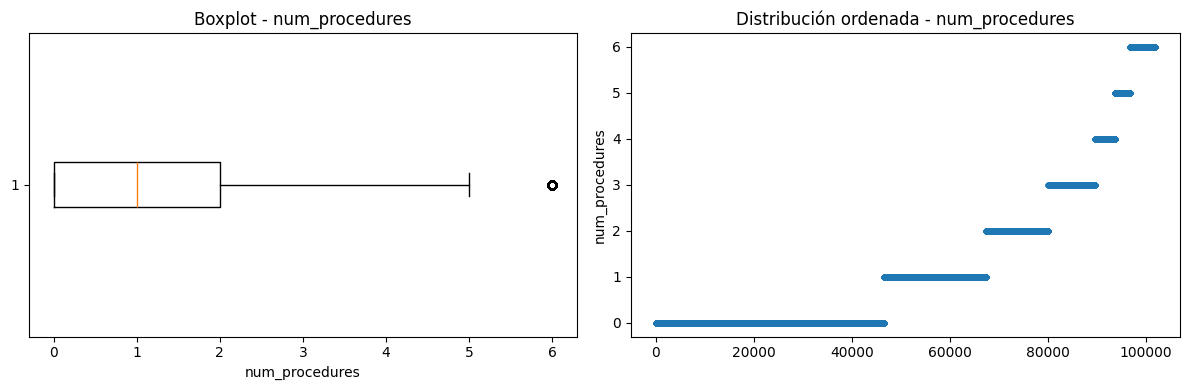

NUM_MEDICATIONS
  Outliers detectados: 2557


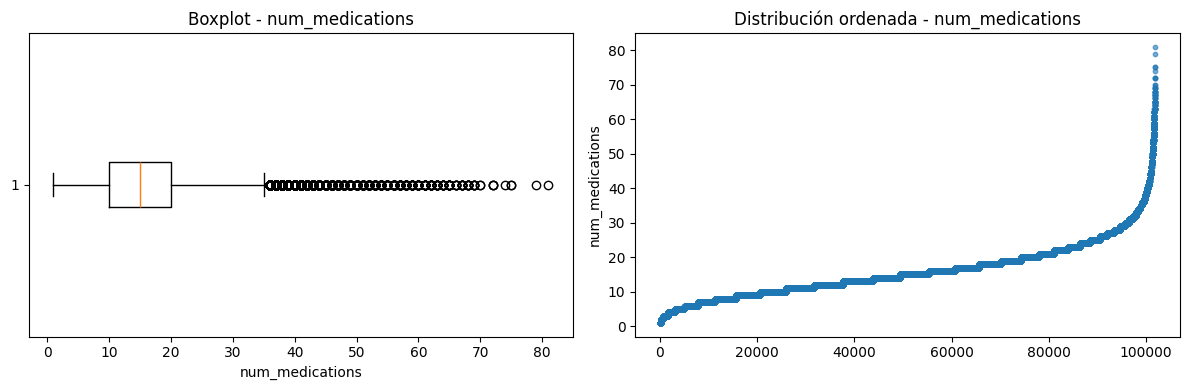

NUMBER_OUTPATIENT
  Outliers detectados: 16739


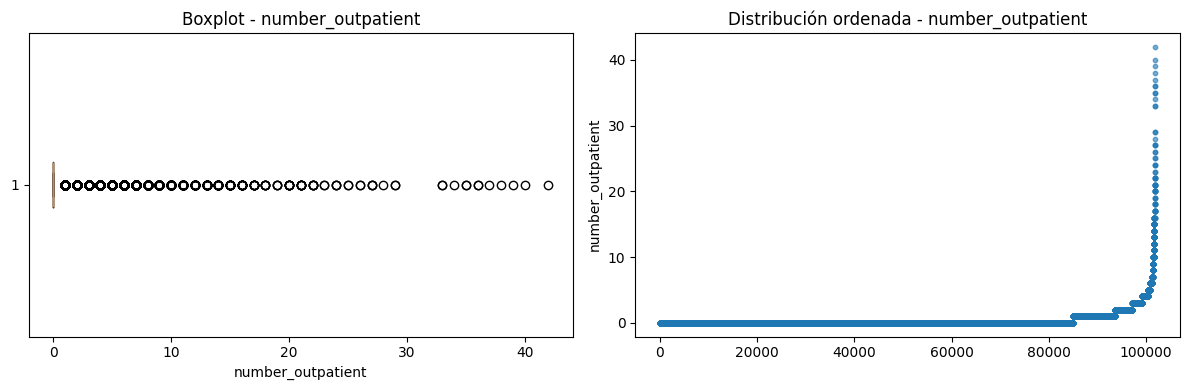

NUMBER_EMERGENCY
  Outliers detectados: 11383


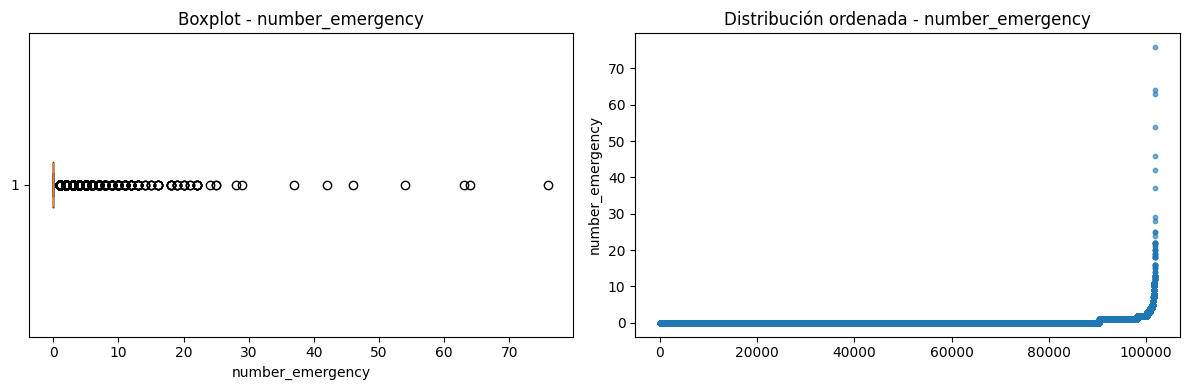

NUMBER_INPATIENT
  Outliers detectados: 7049


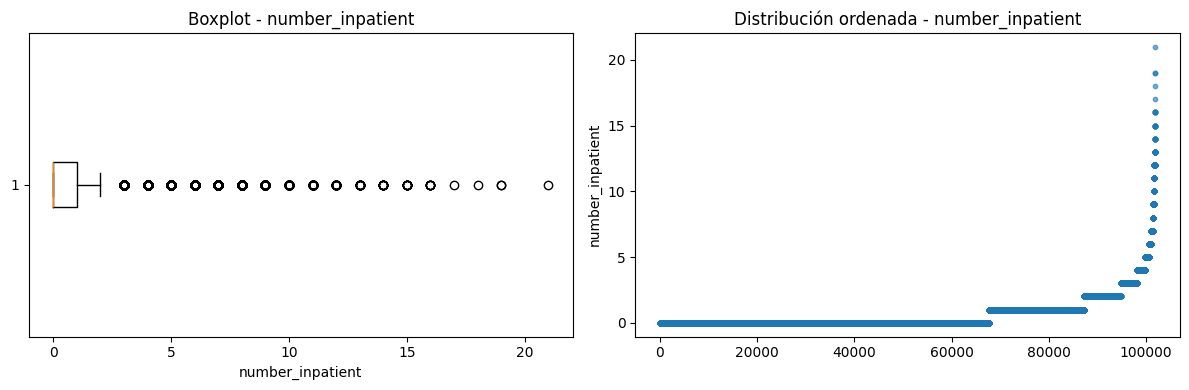

NUMBER_DIAGNOSES
  Outliers detectados: 281


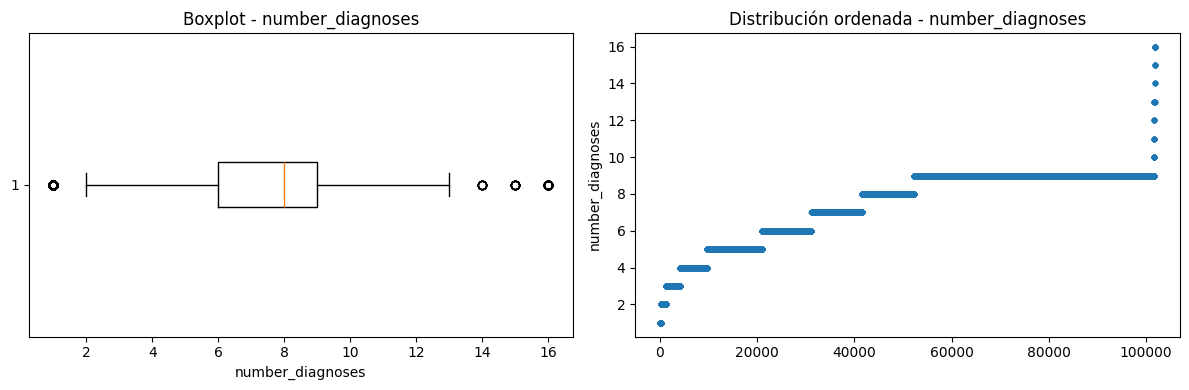

In [75]:
var_num_outliers = df_clean.select_dtypes(include=['number']).columns.values

for variable in var_num_outliers:
    x = df[variable].dropna() 

    # Cálculo del IQR
    Q1 = x.quantile(0.25)
    Q3 = x.quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = (x < lower_bound) | (x > upper_bound)

    print(f"{variable.upper()}")
    print(f"  Outliers detectados: {outliers.sum()}")
                                        
    # Visualización
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Boxplot
    axes[0].boxplot(x.values, vert=False)
    axes[0].set_title(f'Boxplot - {variable}')
    axes[0].set_xlabel(variable)

    # Distribución ordenada
    x_sorted = x.sort_values().reset_index(drop=True) 
    axes[1].scatter(x_sorted.index, x_sorted.values, s=10, alpha=0.6)
    axes[1].set_title(f'Distribución ordenada - {variable}')
    axes[1].set_ylabel(variable)

    plt.tight_layout()
    plt.savefig(f"../outliers/boxplots_{variable}.png")
    plt.show()

En el caso de la variable "num_procedures", el método del rango intercuartílico detecta valores atípicos, concretamente pacientes con un número elevado de procedimientos realizados durante el ingreso. Sin embargo, esta variable solo toma valores entre 0 y 6, por lo que se trata de una variable discreta y acotada. Los valores altos no se consideran errores, ya que pueden corresponder a pacientes con casos más complejos que han necesitado más procedimientos médicos. Además, al tener un rango pequeño, aplicar una transformación logarítmica no aportaría una mejora clara y podría dificultar la interpretación. Por tanto, se decide mantener la variable en su escala original.

En la variable num_medications se observa una distribución claramente asimétrica hacia la derecha, con algunos pacientes que reciben un número muy alto de medicamentos durante la estancia hospitalaria. Estos valores pueden ser considerados atípicos desde el punto de vista estadístico, pero tienen sentido dentro del contexto clínico, ya que pacientes con más enfermedades asociadas o casos más graves pueden necesitar más medicación. No se eliminan estos registros porque podrían contener información importante para predecir la readmisión. Sin embargo, debido a la cola derecha pronunciada y al posible impacto de estos valores extremos en algunos modelos, se decide aplicar una transformación logarítmica, por ejemplo log1p, para reducir su influencia sin perder la información original.

La variable number_outpatient presenta una gran cantidad de valores iguales a cero y una cola derecha muy marcada. Esto indica que la mayoría de pacientes no tuvo visitas ambulatorias previas, mientras que un grupo reducido sí tuvo muchas visitas. Estos valores altos no se consideran errores, ya que pueden representar pacientes con mayor seguimiento médico o con problemas de salud más frecuentes. Como la distribución está muy descompensada y los valores extremos podrían influir demasiado en el entrenamiento del modelo, se decide aplicar una transformación logarítmica log1p. Esta transformación es adecuada porque mantiene los ceros como ceros y reduce el peso de los valores más altos.

En el caso de number_emergency, ocurre algo parecido. La mayoría de pacientes tiene cero visitas a urgencias, pero hay algunos casos con un número muy elevado de visitas. Estos valores pueden parecer outliers, pero son coherentes con el problema, ya que un paciente que ha acudido muchas veces a urgencias puede tener un estado de salud más inestable y, por tanto, mayor riesgo de readmisión. Por este motivo, no se eliminan los valores extremos. No obstante, al existir una cola derecha muy pronunciada, se aplica una transformación logarítmica log1p para suavizar la distribución y evitar que unos pocos valores muy altos dominen el modelo.

La variable number_inpatient también presenta una distribución muy sesgada, con muchos pacientes que no tuvieron ingresos previos y un grupo menor con varios ingresos anteriores. Estos valores altos son relevantes para el problema, ya que el historial de ingresos hospitalarios puede estar relacionado con el riesgo de volver a ingresar. Por tanto, no deben eliminarse como errores. Sin embargo, como la mayoría de observaciones se concentran en valores bajos y existe una cola derecha, se decide aplicar una transformación logarítmica log1p para reducir la influencia de los casos extremos manteniendo la información sobre ingresos previos.

Por último, la variable number_diagnoses contiene algunos valores atípicos detectados por el método IQR, pero su distribución no es tan extrema como en otras variables. Además, el número de diagnósticos está limitado a un rango relativamente pequeño y tiene una interpretación clínica directa: representa la cantidad de diagnósticos registrados para el paciente. Los valores más altos pueden corresponder a pacientes con mayor complejidad médica, por lo que no se consideran errores. En este caso, se decide mantener la variable en su escala original, ya que aplicar una transformación no parece necesario y podría reducir la interpretabilidad de la variable.

En resumen, no se eliminan los outliers detectados, ya que en este dataset representan situaciones clínicas posibles y potencialmente importantes. La decisión principal es aplicar transformación logarítmica a las variables con colas derechas muy marcadas y muchos valores extremos: num_medications, number_outpatient, number_emergency y number_inpatient. En cambio, se mantienen sin transformación num_procedures y number_diagnoses, porque son variables discretas, con rango más limitado y más fáciles de interpretar en su escala original.